## Figure. Reproducing O'brien CB vs Unfiltered

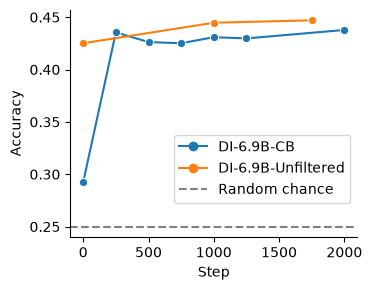

In [ ]:
import json
from pathlib import Path

import pandas as pd
import seaborn as sns

configs = [
    {
        "path": "../artifacts/mila/evals/di-6.9b-lora16-steps2000-wmdp-bio",
        "name": "DI-6.9B-Unfiltered",
    },
    {
        "path": "../artifacts/mila/evals/di-6.9b-cb-lora16-steps2000-wmdp-bio",
        "name": "DI-6.9B-CB",
    },
]

rows = []

for config in configs:
    for checkpoint_dir in Path(config["path"]).glob("checkpoint-*"):
        result_files = list(checkpoint_dir.rglob("results*.json"))

        if not result_files:
            continue

        # Use the newest result if a checkpoint was evaluated more than once.
        result_file = max(result_files, key=lambda path: path.stat().st_mtime)
        results = json.loads(result_file.read_text())

        rows.append(
            {
                "Model": config["name"],
                "Step": int(checkpoint_dir.name.removeprefix("checkpoint-")),
                "Accuracy": results["results"]["wmdp_bio_robust"]["acc,none"],
            }
        )

df = pd.DataFrame(rows).sort_values(["Model", "Step"])
# g = sns.relplot(
#     data=df,
#     x="Step",
#     y="Accuracy",
#     hue="Model",
#     kind="line",
#     marker="o",
#     height=3,
#     aspect=1.3,
# )
# g.ax.axhline(0.25, color="gray", linestyle="--", label="Random chance")

g = sns.relplot(
    data=df,
    x="Step",
    y="Accuracy",
    hue="Model",
    kind="line",
    marker="o",
    height=3,
    aspect=1.3,
    facet_kws={"legend_out": False},
)

g.ax.axhline(
    0.25,
    color="gray",
    linestyle="--",
    label="Random chance",
)

g.ax.legend(
    title=None,
    loc="lower right",
    bbox_to_anchor=(1, 0.12),
)

In [1]:
print("hello")
# !pip install seaborn pandas

hello


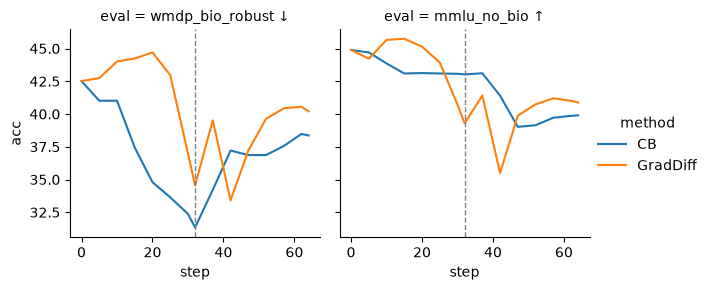

In [16]:
import glob
import json
import os

import pandas as pd
import seaborn as sns

# # ==============================
# # Zephyr 7b
# # ==============================
# midpoint = 125
# configs = [
#     {
#         "path": "../artifacts/tamia/evals/z7b-wmdp-bio-fft-unlearn-npo",
#         "init": "../artifacts/tamia/evals/z7b-wmdp-bio-fft-unlearn-npo",
#         "stage": "Unlearn",
#         "method": "NPO",
#         "offset": 0,
#     },
#     {
#         "path": "../artifacts/tamia/evals/z7b-wmdp-bio-fft-unlearn-npo-relearn",
#         "init": "../artifacts/tamia/evals/z7b-wmdp-bio-fft-unlearn-npo-relearn",
#         "stage": "Relearn",
#         "method": "NPO",
#         "offset": midpoint,
#     },
#     {
#         "path": "../artifacts/tamia/evals/z7b-wmdp-bio-fft-unlearn-gd",
#         "init": "../artifacts/tamia/evals/z7b-wmdp-bio-fft-unlearn-gd",
#         "stage": "Unlearn",
#         "method": "GradDiff",
#         "offset": 0,
#     },
#     {
#         "path": "../artifacts/tamia/evals/z7b-wmdp-bio-fft-unlearn-gd-relearn",
#         "init": "../artifacts/tamia/evals/z7b-wmdp-bio-fft-unlearn-gd-relearn",
#         "stage": "Relearn",
#         "method": "GradDiff",
#         "offset": midpoint,
#     },
# ]


# ==============================
# DI-6.9b
# ==============================
midpoint = 32
configs = [
    {
        "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-cb",
        "init": "../artifacts/mila/evals/di-6.9b-base",
        "stage": "Unlearn",
        "method": "CB",
        "offset": 0,
    },
    {
        "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-cb-relearn",
        "init": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-cb/checkpoint-32",
        "stage": "Relearn",
        "method": "CB",
        "offset": midpoint,
    },
    # {
    #     "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo",
    #     "init": "../artifacts/mila/evals/di-6.9b-base",
    #     "stage": "Unlearn",
    #     "method": "NPO",
    #     "offset": 0,
    # },
    # {
    #     "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo-relearn",
    #     "init": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo/checkpoint-32",
    #     "stage": "Relearn",
    #     "method": "NPO",
    #     "offset": midpoint,
    # },
    # {
    #     "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo-sam",
    #     "init": "../artifacts/mila/evals/di-6.9b-base",
    #     "name": "Unlearn",
    #     "method": "NPO+SAM",
    #     "offset": 0,
    # },
    # {
    #     "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo-sam-relearn",
    #     "init": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo-sam/checkpoint-32",
    #     "name": "Relearn",
    #     "method": "NPO+SAM",
    #     "offset": midpoint,
    # },
    # {
    #     "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo-sam-rho003",
    #     "init": "../artifacts/mila/evals/di-6.9b-base",
    #     "name": "Unlearn",
    #     "method": "NPO+SAM ρ=0.003",
    #     "offset": 0,
    # },
    # {
    #     "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo-sam-gamma225",
    #     "init": "../artifacts/mila/evals/di-6.9b-base",
    #     "name": "Unlearn",
    #     "method": "NPO+SAM γ=2.25",
    #     "offset": 0,
    # },
    # {
    #     "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo-sam-beta015-gamma225",
    #     "init": "../artifacts/mila/evals/di-6.9b-base",
    #     "name": "Unlearn",
    #     "method": "NPO+SAM β=0.015, γ=2.25",
    #     "offset": 0,
    # },
    # {
    #     "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo-sam-rho003-relearn",
    #     "init": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo-sam-rho003/checkpoint-32",
    #     "name": "Relearn",
    #     "method": "NPO+SAM ρ=0.003",
    #     "offset": midpoint,
    # },
    # {
    #     "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo-sam-gamma225-relearn",
    #     "init": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo-sam-gamma225/checkpoint-32",
    #     "name": "Relearn",
    #     "method": "NPO+SAM γ=2.25",
    #     "offset": midpoint,
    # },
    # {
    #     "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo-sam-beta015-gamma225-relearn",
    #     "init": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-npo-sam-beta015-gamma225/checkpoint-32",
    #     "name": "Relearn",
    #     "method": "NPO+SAM β=0.015, γ=2.25",
    #     "offset": midpoint,
    # },
    # {
    #     "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-gd",
    #     "init": "../artifacts/mila/evals/di-6.9b-base",
    #     "name": "Unlearn",
    #     "method": "GradDiff (1.0/1.0)",
    #     "offset": 0,
    # },
    {
        "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-gd",
        "init": "../artifacts/mila/evals/di-6.9b-base",
        "stage": "Unlearn",
        "method": "GradDiff",
        "offset": 0,
    },
    {
        "path": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-gd-relearn",
        "init": "../artifacts/mila/evals/di-6.9b-wmdp-bio-lora-unlearn-gd/checkpoint-32",
        "stage": "Relearn",
        "method": "GradDiff",
        "offset": midpoint,
    },
]


name_to_name = {
    "wmdp_bio_robust": "wmdp_bio_robust ↓",
    "mmlu_no_bio": "mmlu_no_bio ↑",
}


def get_tasks(checkpoint):
    tasks = []
    for path in glob.glob(
        os.path.join(checkpoint, "**", "results*.json"), recursive=True
    ):
        with open(path) as f:
            results = json.load(f)["results"]

        for name in ("wmdp_bio_robust", "mmlu_no_bio"):
            if name in results:
                tasks.append(
                    {"name": name_to_name[name], "acc": 100 * results[name]["acc,none"]}
                )
    return tasks


rows = []
for config in configs:
    if "init" in config:
        for task in get_tasks(config["init"]):
            rows.append(
                {
                    "stage": config["stage"],
                    "method": config["method"],
                    "step": config["offset"],
                    "eval": task["name"],
                    "acc": task["acc"],
                }
            )

    checkpoints = glob.glob(os.path.join(config["path"], "checkpoint-*"))
    checkpoints.sort(key=lambda p: int(os.path.basename(p).split("-")[-1]))

    for checkpoint in checkpoints:
        step = int(os.path.basename(checkpoint).split("-")[-1]) + config["offset"]
        for task in get_tasks(checkpoint):
            rows.append(
                {
                    "stage": config["stage"],
                    "method": config["method"],
                    "step": step,
                    "eval": task["name"],
                    "acc": task["acc"],
                }
            )

df = pd.DataFrame(rows)

g = sns.relplot(
    data=df, x="step", y="acc", col="eval", hue="method", kind="line", height=3
)

for ax in g.axes.flat:
    ax.axvline(midpoint, color="gray", linestyle="--", linewidth=1)

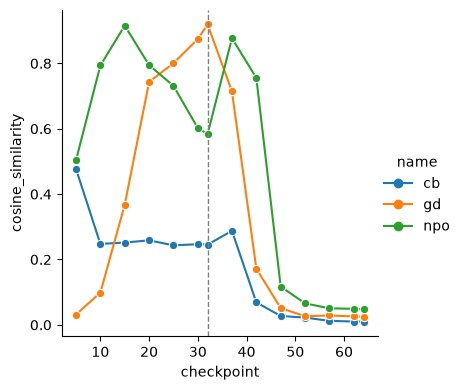

In [21]:
import glob
import json
import os
import os.path as osp
import re

import pandas as pd
import seaborn as sns

root = "../artifacts/mila/analysis/per_sample_param_grad_cosim"
configs = [
    # cb
    {
        "name": "cb",
        "path": osp.join(root, "di-6.9b-wmdp-bio-lora-unlearn-cb"),
        "offset": 0,
    },
    {
        "name": "cb",
        "path": osp.join(root, "di-6.9b-wmdp-bio-lora-unlearn-cb-relearn"),
        "offset": 32,
    },
    # gd
    {
        "name": "gd",
        "path": osp.join(root, "di-6.9b-wmdp-bio-lora-unlearn-gd"),
        "offset": 0,
    },
    {
        "name": "gd",
        "path": osp.join(root, "di-6.9b-wmdp-bio-lora-unlearn-gd-relearn"),
        "offset": 32,
    },
    # npo
    {
        "name": "npo",
        "path": osp.join(root, "di-6.9b-wmdp-bio-lora-unlearn-npo"),
        "offset": 0,
    },
    {
        "name": "npo",
        "path": osp.join(root, "di-6.9b-wmdp-bio-lora-unlearn-npo-relearn"),
        "offset": 32,
    },
]

rows = []
for config in configs:
    files = sorted(
        glob.glob(os.path.join(config["path"], "checkpoint-*.json")),
        key=lambda path: int(re.search(r"checkpoint-(\d+)", path).group(1)),
    )
    for path in files:
        with open(path) as f:
            result = json.load(f)
        rows.append(
            {
                "name": config["name"],
                "checkpoint": int(re.search(r"checkpoint-(\d+)", path).group(1))
                + config["offset"],
                "cosine_similarity": result["avg_cosine_similarity"],
            }
        )

df = pd.DataFrame(rows)
g = sns.relplot(
    data=df,
    x="checkpoint",
    y="cosine_similarity",
    hue="name",
    kind="line",
    marker="o",
    height=4,
)

for ax in g.axes.flat:
    ax.axvline(32, color="gray", linestyle="--", linewidth=1)